In [1]:
import pandas as pd
import numpy as np
df = pd.read_excel("heart_disease.xlsx", sheet_name="Heart_disease")
df.head(10)       

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0
5,66,Male,asymptomatic,160,228,False,lv hypertrophy,138,False,2.3,upsloping,fixed defect,0
6,56,Male,non-anginal,130,276,False,normal,128,True,1.0,upsloping,fixed defect,0
7,48,Male,non-anginal,110,211,False,normal,138,False,0.0,downsloping,fixed defect,0
8,57,Male,atypical angina,140,260,True,normal,140,False,0.0,downsloping,fixed defect,0
9,53,Male,non-anginal,155,175,True,st-t abnormality,160,False,NaN,upsloping,fixed defect,0


In [2]:
df.shape    

(908, 13)

In [3]:
df.info() 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [4]:
df.isnull().sum() 

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [5]:
print(df['exang'].unique())
print(df['thal'].unique())
print(df['num'].unique())

[False True 'FALSE' 'TURE']
['fixed defect' 'normal' 'reversable defect']
[0 1 2 3 4]


In [6]:
df['oldpeak'] = df['oldpeak'].fillna(df['oldpeak'].median())

In [7]:
df['exang'] = df['exang'].map({True: 1, False: 0, 'TURE': 1, 'FALSE': 0})

In [8]:
print(df['exang'].unique())

[0 1]


In [9]:
df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

In [10]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,0,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,0,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,0,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,0,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,1,1.5,flat,fixed defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,Male,asymptomatic,125,0,False,normal,120,0,1.5,upsloping,normal,1
904,62,Male,asymptomatic,166,170,False,st-t abnormality,120,1,3.0,flat,reversable defect,1
905,56,Male,non-anginal,170,0,False,lv hypertrophy,123,1,2.5,downsloping,reversable defect,1
906,56,Male,non-anginal,144,208,True,st-t abnormality,105,1,0.5,downsloping,reversable defect,1


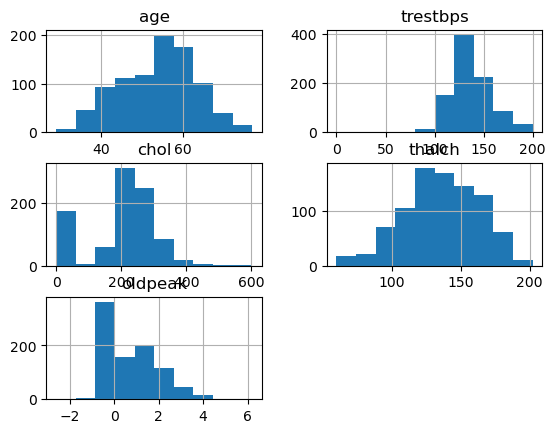

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
numeric_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
df[numeric_cols].hist()
plt.show()

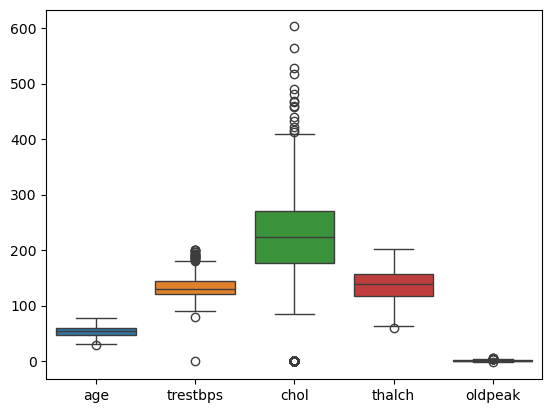

In [12]:
sns.boxplot(data=df[numeric_cols])
plt.show()

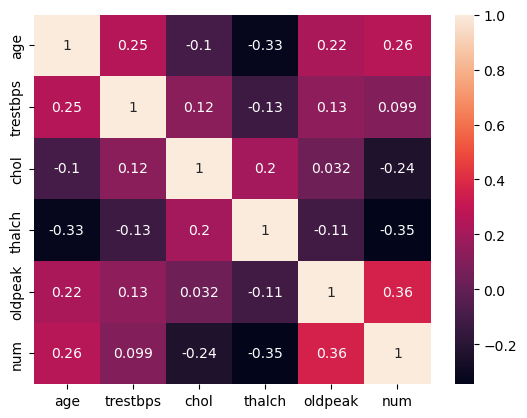

In [13]:
sns.heatmap(df[numeric_cols + ['num']].corr(), annot=True)
plt.show()

In [14]:
cat_cols = ['sex', 'cp', 'restecg', 'slope', 'thal']

In [15]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [16]:
df.head()

,age,trestbps,chol,fbs,thalch,exang,oldpeak,num,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145,233,True,150,0,2.3,0,True,False,False,True,False,False,False,False,False,False
1,41,135,203,False,132,0,0.0,0,True,True,False,False,True,False,True,False,False,False
2,57,140,192,False,148,0,0.4,0,True,False,False,False,True,False,True,False,False,False
3,52,118,186,False,190,0,0.0,0,True,False,False,True,False,False,True,False,False,False
4,57,110,201,False,126,1,1.5,0,True,False,False,False,True,False,True,False,False,False


In [17]:
df = df.replace({True: 1, False: 0})

C:\Users\shiva\AppData\Local\Temp\ipykernel_18516\3074727906.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({True: 1, False: 0})


In [18]:
df.head()

,age,trestbps,chol,fbs,thalch,exang,oldpeak,num,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145,233,1,150,0,2.3,0,1,0,0,1,0,0,0,0,0,0
1,41,135,203,0,132,0,0.0,0,1,1,0,0,1,0,1,0,0,0
2,57,140,192,0,148,0,0.4,0,1,0,0,0,1,0,1,0,0,0
3,52,118,186,0,190,0,0.0,0,1,0,0,1,0,0,1,0,0,0
4,57,110,201,0,126,1,1.5,0,1,0,0,0,1,0,1,0,0,0


In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numeric_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
df.head()

,age,trestbps,chol,fbs,thalch,exang,oldpeak,num,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,1.006027,0.567394,0.281297,1,0.524183,0,1.354403,0,1,0,0,1,0,0,0,0,0,0
1,-1.397560,0.076967,0.013526,0,-0.147705,0,-0.815718,0,1,1,0,0,1,0,1,0,0,0
2,0.350503,0.322181,-0.084656,0,0.449529,0,-0.438305,0,1,0,0,0,1,0,1,0,0,0
3,-0.195767,-0.756760,-0.138211,0,2.017268,0,-0.815718,0,1,0,0,1,0,0,1,0,0,0
4,0.350503,-1.149102,-0.004325,0,-0.371668,1,0.599578,0,1,0,0,0,1,0,1,0,0,0


In [20]:
from sklearn.model_selection import train_test_split
X = df.drop('num', axis=1)
y = df['num']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(f"Training rows: {X_train.shape[0]}")
print(f"Testing rows: {X_test.shape[0]}")

Training rows: 726
Testing rows: 182


In [21]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [22]:
model = DecisionTreeClassifier(criterion='gini', max_depth=6, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [23]:
print("Accuracy:  ", np.round(accuracy_score(y_test, y_pred), 2))
print("Precision: ", np.round(precision_score(y_test, y_pred), 2))
print("Recall:    ", np.round(recall_score(y_test, y_pred), 2))
print("F1-Score:  ", np.round(f1_score(y_test, y_pred), 2))
print("ROC-AUC:   ", np.round(roc_auc_score(y_test, y_prob), 2))

Accuracy:   0.78
Precision:  0.78
Recall:     0.8
F1-Score:   0.79
ROC-AUC:    0.79


In [24]:
model = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [25]:
print("Accuracy:  ", np.round(accuracy_score(y_test, y_pred), 2))
print("Precision: ", np.round(precision_score(y_test, y_pred), 2))
print("Recall:    ", np.round(recall_score(y_test, y_pred), 2))
print("F1-Score:  ", np.round(f1_score(y_test, y_pred), 2))
print("ROC-AUC:   ", np.round(roc_auc_score(y_test, y_prob), 2))

Accuracy:   0.76
Precision:  0.72
Recall:     0.88
F1-Score:   0.79
ROC-AUC:    0.81


C:\Users\shiva\AppData\Local\Temp\ipykernel_18516\764150499.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


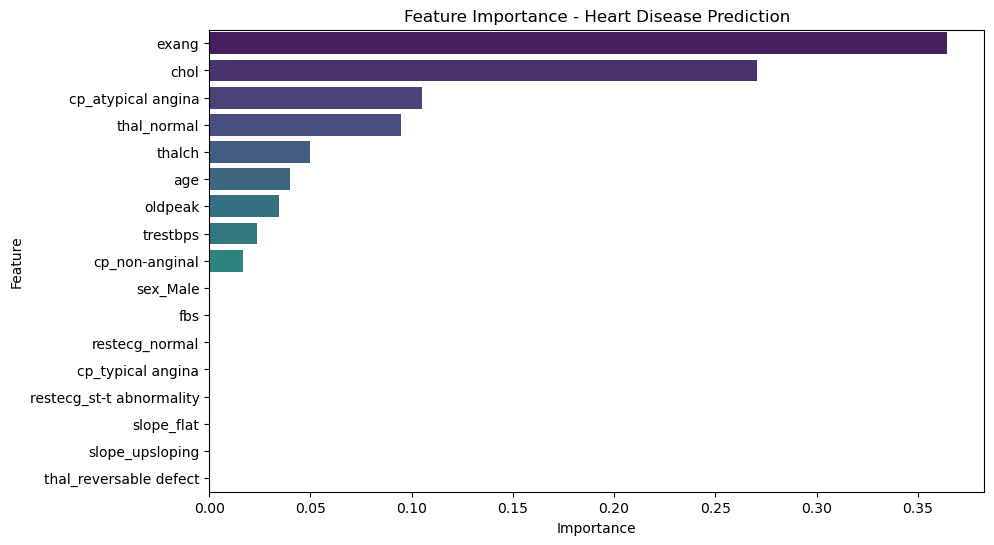

Top 3 most important features for predicting heart disease:
              Feature  Importance
5               exang    0.364568
2                chol    0.270688
8  cp_atypical angina    0.105148


In [26]:
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance - Heart Disease Prediction')
plt.show()
print("Top 3 most important features for predicting heart disease:")
print(feature_importance_df.head(3))

In [28]:
from sklearn.model_selection import GridSearchCV

In [31]:
param_grid = {
    'max_depth': [3, 5, 7, 9],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

In [32]:
dt = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 9],
                         'min_samples_split': [2, 5, 10]})

In [33]:
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'criterion': 'gini', 'max_depth': 7, 'min_samples_split': 10}


In [34]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

In [35]:
print("Accuracy:  ", np.round(accuracy_score(y_test, y_pred), 2))
print("Precision: ", np.round(precision_score(y_test, y_pred), 2))
print("Recall:    ", np.round(recall_score(y_test, y_pred), 2))
print("F1-Score:  ", np.round(f1_score(y_test, y_pred), 2))
print("ROC-AUC:   ", np.round(roc_auc_score(y_test, y_prob), 2))

Accuracy:   0.76
Precision:  0.78
Recall:     0.74
F1-Score:   0.76
ROC-AUC:    0.8


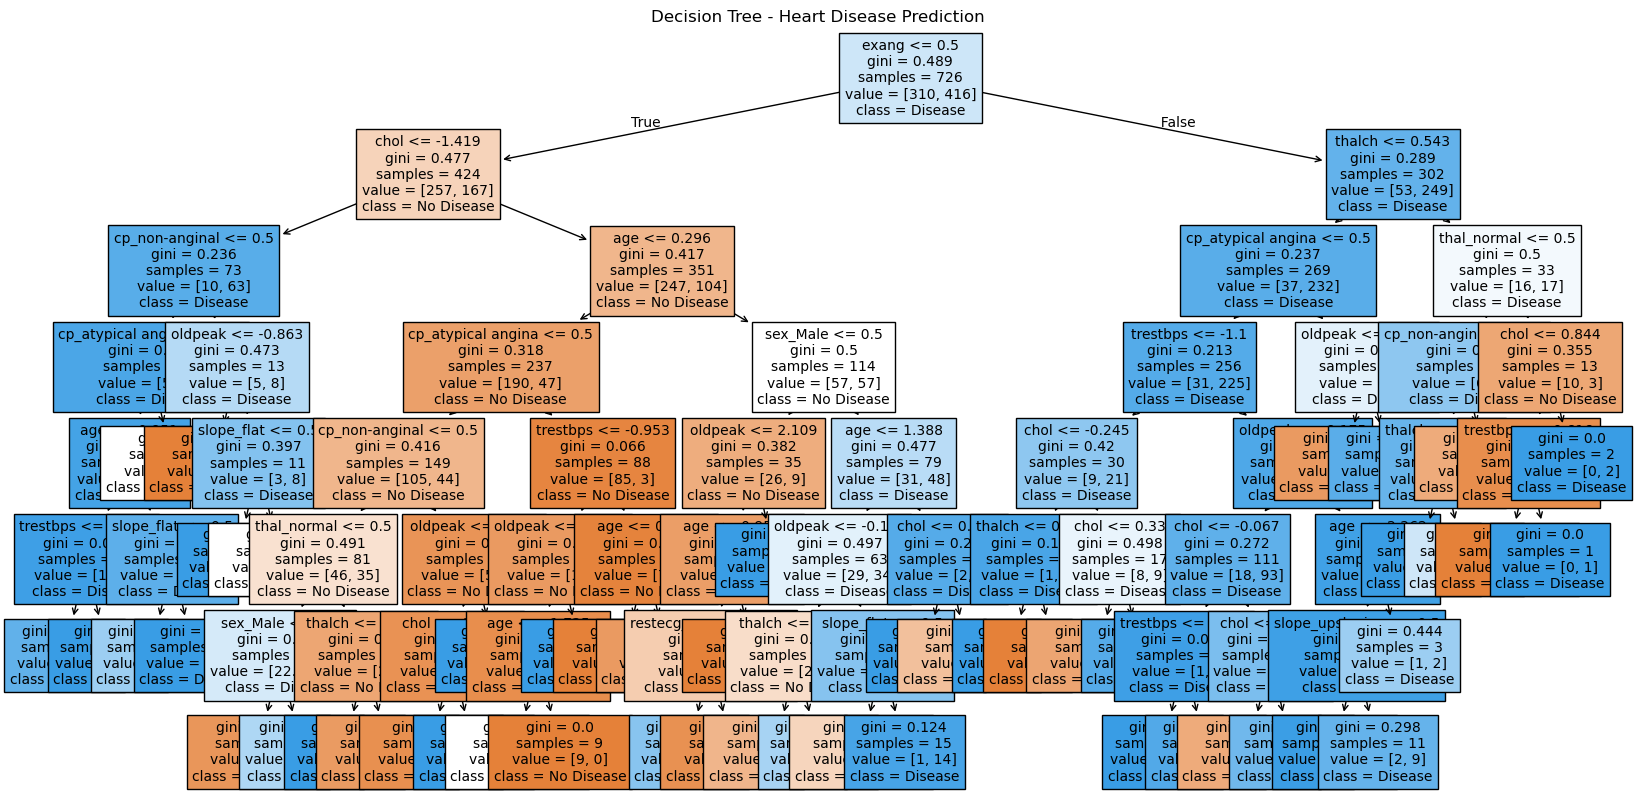

In [36]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 10))
plot_tree(
    best_model,
    feature_names=X.columns.tolist(),
    class_names=['No Disease', 'Disease'],
    filled=True,
    fontsize=10)
plt.title("Decision Tree - Heart Disease Prediction")
plt.show()

In [38]:
print("Number of nodes:", best_model.tree_.node_count)
print("Tree depth:", best_model.get_depth())

Number of nodes: 97
Tree depth: 7


# Q1
What are some common hyperparameters of decision tree models, and how do they affect the model's performance?

1.max_depth: Controls how deep the tree can grow. A very deep tree may overfit, while a shallow tree may underfit.


2.min_samples_split: Sets the minimum number of samples required to split a node. Smaller values allow more splits (risk of overfitting), larger values restrict splitting (risk of underfitting).


3.criterion: Defines how the quality of a split is measured. Common options are gini (impurity) and entropy (information gain). Both often give similar results, but one may perform slightly better depending on the dataset.
Overall, these hyperparameters regulate the complexity of the tree. Higher complexity improves training accuracy but increases the risk of overfitting, while stricter limits reduce complexity and improve generalization but may cause underfitting.


# Q2:
What is the difference between Label Encoding and One-Hot Encoding?

1.Label Encoding: Converts categories into numeric values (0, 1, 2, …). This can unintentionally imply an order or ranking between categories, so it should only be used when the categories have a natural order (e.g., low, medium, high).


2.One-Hot Encoding: Creates separate binary (0/1) columns for each category. This avoids false ordering and treats all categories equally, making it suitable when categories have no natural order.
